# Figure 4B — Monocle3 pseudotime and *Nedd4* expression

This notebook reconstructs the manuscript panel from the condition-specific Monocle3 objects. It uses size-factor-normalized expression and a descriptive GAM smoother. Cells are not biological replicates, so no cell-level group P value is reported.


In [1]:
source(if (file.exists('../config/paths.R')) '../config/paths.R' else 'config/paths.R')
suppressPackageStartupMessages({
  library(monocle3)
  library(ggplot2)
  library(dplyr)
  library(Matrix)
})
set.seed(1234)


In [2]:
input_rds <- p38_path('20260126p38拟时序修图', 'monocle3_results_combined.rds')
figure_dir <- file.path(p38_output_root, 'figures', 'Fig4B_Nedd4_pseudotime')
dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)
stopifnot(file.exists(input_rds))
monocle_results <- readRDS(input_rds)
stopifnot(all(c('wt_cds', 'ko_cds') %in% names(monocle_results)))


In [3]:
extract_nedd4 <- function(cds, condition, gene = 'Nedd4') {
  gene_names <- rowData(cds)$gene_short_name
  if (is.null(gene_names)) gene_names <- rownames(cds)
  gene_index <- which(tolower(gene_names) == tolower(gene))
  if (length(gene_index) != 1L) stop('Expected one row for ', gene, '; found ', length(gene_index))
  pseudotime_values <- pseudotime(cds)[colnames(cds)]
  counts <- SummarizedExperiment::assay(cds, 'counts')
  raw_counts <- as.numeric(counts[gene_index, ])
  sf <- monocle3::size_factors(cds)
  if (is.null(sf) || any(!is.finite(sf)) || any(sf <= 0)) {
    library_size <- Matrix::colSums(counts)
    sf <- library_size / median(library_size[library_size > 0])
  }
  tibble(
    Cell = colnames(cds),
    Condition = condition,
    Pseudotime = as.numeric(pseudotime_values),
    RawCount = raw_counts,
    NormalizedExpression = raw_counts / sf,
    Log1pNormalizedExpression = log1p(raw_counts / sf)
  ) |> filter(is.finite(Pseudotime), is.finite(Log1pNormalizedExpression))
}
nedd4_data <- bind_rows(
  extract_nedd4(monocle_results$wt_cds, 'WT'),
  extract_nedd4(monocle_results$ko_cds, 'p38a-dMPC')
) |> mutate(Condition = factor(Condition, levels = c('WT', 'p38a-dMPC')))


In [4]:
condition_summary <- nedd4_data |>
  group_by(Condition) |>
  summarise(
    Cells = n(),
    PseudotimeMin = min(Pseudotime),
    PseudotimeMax = max(Pseudotime),
    MeanLog1pNormalizedExpression = mean(Log1pNormalizedExpression),
    MedianLog1pNormalizedExpression = median(Log1pNormalizedExpression),
    PercentExpressing = 100 * mean(RawCount > 0),
    .groups = 'drop'
  )
binned_summary <- nedd4_data |>
  group_by(Condition) |>
  mutate(PseudotimeBin = ntile(Pseudotime, 25L)) |>
  group_by(Condition, PseudotimeBin) |>
  summarise(
    Cells = n(), MedianPseudotime = median(Pseudotime),
    MeanLog1pNormalizedExpression = mean(Log1pNormalizedExpression),
    MedianLog1pNormalizedExpression = median(Log1pNormalizedExpression),
    PercentExpressing = 100 * mean(RawCount > 0), .groups = 'drop'
  )
write.csv(nedd4_data, file.path(figure_dir, 'Fig4B_Nedd4_cell_level_data.csv'), row.names = FALSE)
write.csv(condition_summary, file.path(figure_dir, 'Fig4B_Nedd4_condition_summary.csv'), row.names = FALSE)
write.csv(binned_summary, file.path(figure_dir, 'Fig4B_Nedd4_pseudotime_bins.csv'), row.names = FALSE)
condition_summary


"Condition","Cells","PseudotimeMin","PseudotimeMax","MeanLog1pNormalizedExpression","MedianLog1pNormalizedExpression","PercentExpressing"
"WT",9328,0,34.8932165980161,0.000132067743643314,0,46.5158662092624
"p38a-dMPC",8785,0,25.2880851242,3.20950436307173e-05,0,16.5167899829254


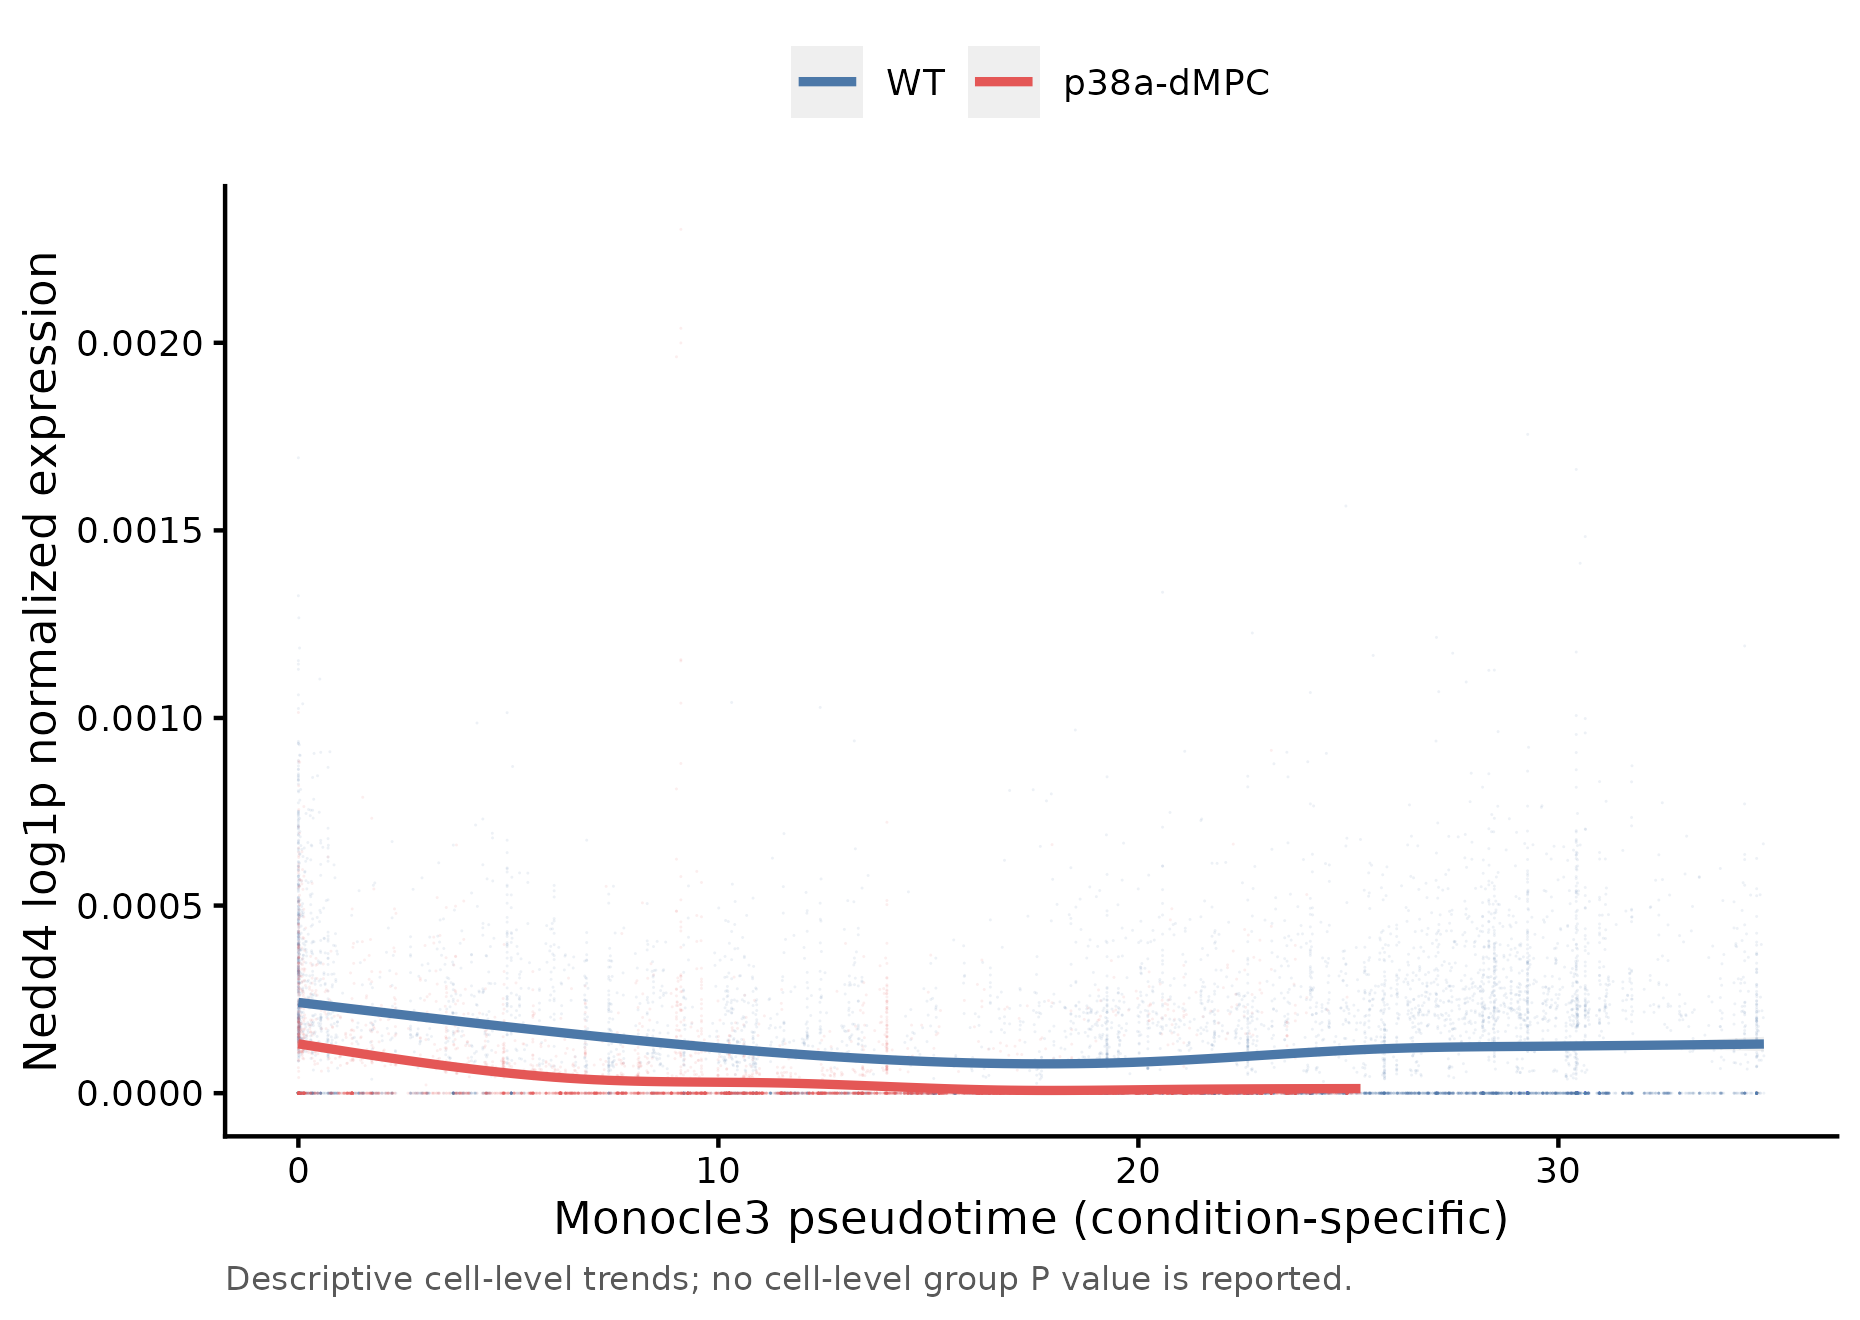

In [5]:
condition_colors <- c('WT' = '#4C78A8', 'p38a-dMPC' = '#E45756')
fig4b <- ggplot(nedd4_data, aes(Pseudotime, Log1pNormalizedExpression, color = Condition)) +
  geom_point(alpha = 0.10, size = 0.35, stroke = 0) +
  geom_smooth(method = 'gam', formula = y ~ s(x, bs = 'cs', k = 6), se = TRUE, linewidth = 1.05, alpha = 0.16) +
  scale_color_manual(values = condition_colors, drop = FALSE) +
  labs(
    x = 'Monocle3 pseudotime (condition-specific)',
    y = 'Nedd4 log1p normalized expression', color = NULL,
    caption = 'Descriptive cell-level trends; no cell-level group P value is reported.'
  ) +
  theme_classic(base_size = 11) +
  theme(legend.position = 'top', axis.text = element_text(color = 'black'),
        plot.caption = element_text(size = 8, color = 'grey35', hjust = 0))
ggsave(file.path(figure_dir, 'Fig4B_Nedd4_pseudotime.pdf'), fig4b, width = 6.2, height = 4.4, device = cairo_pdf)
ggsave(file.path(figure_dir, 'Fig4B_Nedd4_pseudotime.png'), fig4b, width = 6.2, height = 4.4, dpi = 300, bg = 'white')
fig4b
